### Data Generators

In [ ]:


class DataGenerator:


    def data_gen(self):
        for patient in patients:
            # mesh is a customObject inherited from pv mesh object 
            img = load(patient)
            boundary_conditions = load(patient_bcs)
            if fileexists(tempdir/patient):
                out_dict = read(tempdir/patient)
            else:
                mesh = Mesh(file_list, feature_keys = ['pressure', ...], ids= {"volume":0, "surface":1, "inlets":2, "outlet1":3,"outlet2":4}, fixed_coords=True, fixed_connectivity=True)
                mesh.scale_features(feature_scaler)
                mesh.temporal_pca(PCA)
                mesh.filter_adjacency(filter_type, filter_degree, ["volume"], keep_original=False)
                mesh.compute_normals(["inlet", "outlet1" ,"outlet2"])
                out_dict = mesh.to_dict()
            yield {'img':img, 'boundary':boundary_conditions}, out_dict 
    
    def get_signature(self):
        # gets the output signature of the data generator



# The data generator has can be made by subclassing the DataGenerator and adding a custom data_gen or by using one of the presets
# The get_signature function returns the signature of the function you create 
# The inputs are formatted for your model structure, outputs are dict(points, features, pca_features and structure_adjacency,... )
# The contents of each sub category is user-specified
# Custom calculated values can be added to the final dict
# put Mesh functions in a utils file outside of the object so you can use it functionally also

In [ ]:

class Loss:
    def __init__(self, structures, name):

    def call(args):

    def get_keys(self):
        # return [structure_arg for stucture, arg in self.structures, self.call.args]

class CustomLoss(Loss):
    def call(adjacency, features):
        ...

# All losses will return keys needed for the loss based on the structure it was initialised with
# The losses are subclassed from Im2SimLoss and the call function keys are used for mapping
cap_loss = CapLoss(structures = ["inlet", "outlet1" ,"outlet2"])
surface_chamfer = ChamferLoss(structures=["surface"])
volume_chamfer = ChamferLoss(structures=["volume"])



In [ ]:
class Model(tf.keras.Model):
    def set_losses(losses):
        # self.losses = losses
    def train_step(self, data):
        x, y_true = data

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            # Use compiled loss (supports any loss passed in compile)
            for key in self.losses.keys(): # coords/features 
                for i, loss in enumerate(self.losses[key]):
                    keys = loss.get_keys()
                    self.loss_vals[key][i] = loss(y_pred[key], y_true[keys])
            for key in y_pred.keys():
                if 'residual' in key:
                    self.lossvals[key][i] = y_pred[key]

        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        # Update compiled metrics
        self.compiled_metrics.update_state(y_true, y_pred)
        
        # Return a dict mapping metric names to current value
        return {m.name: m.result() for m in self.metrics}
    

image_input = Input((None,None,None,1))
enc = ImageEncoder(*args)(image_input)
template_input = Input((None, 7))
boundary_condition_input = Input((None, 7))
dec = GraphDecoder(*args)([enc, template_input, boundary_condition_input])
phys_block = NavierStokes(*args)(dec)

model = Im2SimModel(image_input, phys_block)
model.set_losses(losses)

model.compile()

model.fit()

In [ ]:
import torch
from torch_geometric.data import Dataset, DataLoader, Data
import pyvista as pv

class FileGraphDataset(Dataset):
    def __init__(self, root, file_list, transform=None, pre_transform=None):
        self.file_list = file_list  # list of file paths
        super().__init__(root, transform, pre_transform)

    def len(self):
        return len(self.file_list)

    def get(self, idx):
        # Load a single mesh from file
        data = pv.read(self.file_list[idx])
    
        # if self.transform:
        #     data = self.transform(data)
        return data


In [11]:
import pyvista as pv
import numpy as np

graph = pv.read('test_data/clipped_template-0301.vtu')
print(graph.points)
print(graph['CellEntityIds'])


[[50.76766  76.39622  69.129005]
 [50.522057 77.538574 70.06679 ]
 [51.79816  77.57999  69.06595 ]
 ...
 [58.495686 75.779205 77.83442 ]
 [59.710613 70.33089  78.638535]
 [55.502327 67.67366  72.53992 ]]
[0 0 0 ... 4 1 4]


In [15]:
subgraph = graph.extract_cells(np.where(graph['CellEntityIds'] == 0)[0])
print(len(subgraph.cells)/5)
print(len(graph['CellEntityIds']))

62975.0
66929


In [ ]:
mesh.offset

array([     0,      4,      8, ..., 263756, 263759, 263762],
      shape=(66930,))

In [ ]:
mesh.cells

array([   4, 5299, 6404, ...,  349, 1689,  354], shape=(330691,))

In [20]:
cells = []
for i in range(len(graph.offset)-1):
    cells.append(graph.cells[graph.offset[i]:graph.offset[i+1]])
cells = np.stack(cells, axis=0)
print(cells.shape)

ValueError: all input arrays must have the same shape

In [22]:
print(cells[-1])

[9309    4 5744]


In [27]:
cell_ids = np.zeros((len(graph.points),))
for i in range(len(graph.offset)-1):
    cell = graph.cells[graph.offset[i]:graph.offset[i+1]]
    cell_entity = graph['CellEntityIds'][i]
    cell_ids[cell] = cell_entity

In [ ]:
cell_ids = np.zeros((len(graph.points),))
for id in np.unique(graph['CellEntityIds']):
    cells = graph.extract_cells(np.where(graph['CellEntityIds'] == id)[0])['vtkOriginalPointIds']
    # print(cells.cells)
    nodes = np.unique(cells)
    print(nodes)
    # print(nodes)
    cell_ids[nodes] = id



[    0     1     2 ... 10984 10985 10986]
[   0    1    2 ... 1975 1976 1977]
[  44   45   59   60  268  269  273  274  645  646  651  731  902  903
  904  914  915  916  923  924  952  953  954  967  968  993  994 1006
 1007 1008 1083 1084 1085 1094 1095 1101 1178 1179 1180 1187 1188 1189
 1190 1206 1207 1208 1209 1233 1248 1253 1273 1300 1301 1305 1306 1315
 1316 1357 1361 1362 1372 1373 1413 1414 1419 1431 1437 1445 1446 1447
 1458 1472 1487 1497 1514 1515 1533 1582 1591 1616 1617 1636 1656 1670
 1677 1698 1713 1769 1793 1809 1815 1816 1846 1866 1874 1895 1931]
[  35   36   50   52   94  153  186  188  200  326  465  466  467  505
  506  507  528  529  530  531  532  533  570  571  599  600  610  611
  612  613  614  615  631  662  666  667  668  726  729  732  764  785
  786  787  849  898  899  900  901  936  983 1037 1119 1120 1168 1169
 1170 1235 1236 1237 1240 1288 1295 1296 1297 1366 1394 1411 1428 1429
 1507 1508 1509 1637 1696 1712 1813 1820 1859 1888 1910 1935 1941 1967]
[ 

In [137]:
from itertools import combinations

tet_cells = graph.extract_cells(np.where(graph['CellEntityIds'] == 0)[0])
tet_cells = tet_cells.cells.reshape(-1, 5)[:, 1:]
edges = np.reshape(np.array([list(combinations(cell,2)) for cell in tet_cells]), [-1,2])
edges = np.unique(edges, axis=0)
edges = np.concat([edges, np.stack([edges[...,1], edges[...,0]], axis=-1)], axis=0)

In [138]:
edges.shape

(260140, 2)

In [84]:
tri_cells = graph.extract_cells(np.where(graph['CellEntityIds'] == 1)[0])
tri_cells.cells.reshape(-1, 4)[:, 1:]

array([[   0,    2,    1],
       [   1,    2,    3],
       [   5,    4,    6],
       ...,
       [1656, 1667,  735],
       [ 735, 1667, 1635],
       [1526, 1441, 1651]], shape=(3243, 3))

In [67]:
cell_ids

array([1., 1., 1., ..., 0., 0., 0.], shape=(10987,))

array([ 914, 1656])

In [ ]:
arr = np.where(edges==1656)[0]


array([14850, 14853, 14854, 17940, 17943, 17944, 24984, 24987, 24988,
       37465, 37467, 37469, 58398, 58401, 58402, 71298, 71301, 71302,
       75252, 75253, 75254, 75258, 75261, 75262])

In [127]:
arr = edges[node_edges][0]
arr.tolist().remove(0)
arr

array([   0, 6196])

In [145]:
idxs = np.squeeze(np.argwhere(cell_ids==0))
# ref_dict={}
# for idx in idxs:
#     node_edges = np.where(edges==idx)
#     connected_nodes = np.unique(edges[node_edges[0], 1-node_edges[1]])
#     part_nodes = connected_nodes[np.isin(connected_nodes, idxs)]
#     ref_dict[idx] = part_nodes
# ref_dict

In [146]:
from collections import defaultdict

adj = defaultdict(set)
for a, b in edges:
    adj[a].add(b)
    adj[b].add(a)

tets = set()

for i in idxs:
    for j in adj[i]:
        if j <= i: continue
        for k in adj[i] & adj[j]:
            if k <= j: continue
            for l in adj[i] & adj[j] & adj[k]:
                if l <= k: continue
                tets.add(tuple(sorted((i, j, k,l))))
tets

{(np.int64(2957), np.int64(4189), np.int64(4435), np.int64(6446)),
 (np.int64(3804), np.int64(5610), np.int64(5612), np.int64(7650)),
 (np.int64(3794), np.int64(6640), np.int64(7121), np.int64(10267)),
 (np.int64(2132), np.int64(2413), np.int64(4765), np.int64(6829)),
 (np.int64(2061), np.int64(4530), np.int64(6922), np.int64(8791)),
 (np.int64(2924), np.int64(4158), np.int64(5279), np.int64(7334)),
 (np.int64(3034), np.int64(6122), np.int64(6551), np.int64(8157)),
 (np.int64(2192), np.int64(2828), np.int64(6200), np.int64(6204)),
 (np.int64(5998), np.int64(9425), np.int64(9922), np.int64(9923)),
 (np.int64(2204), np.int64(2861), np.int64(4295), np.int64(6264)),
 (np.int64(2176), np.int64(6516), np.int64(7775), np.int64(8497)),
 (np.int64(2086), np.int64(4541), np.int64(8470), np.int64(9505)),
 (np.int64(2907), np.int64(4368), np.int64(5691), np.int64(9191)),
 (np.int64(2540), np.int64(3812), np.int64(5618), np.int64(8207)),
 (np.int64(4417), np.int64(6430), np.int64(6741), np.int64(83

/var/folders/6l/jpv7zwr94bv3sdj5l1tsm_lw0000gn/T/ipykernel_67289/1749145157.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(data[:,0], data[:,1], data[:,2], cmap='viridis', alpha=0.8)


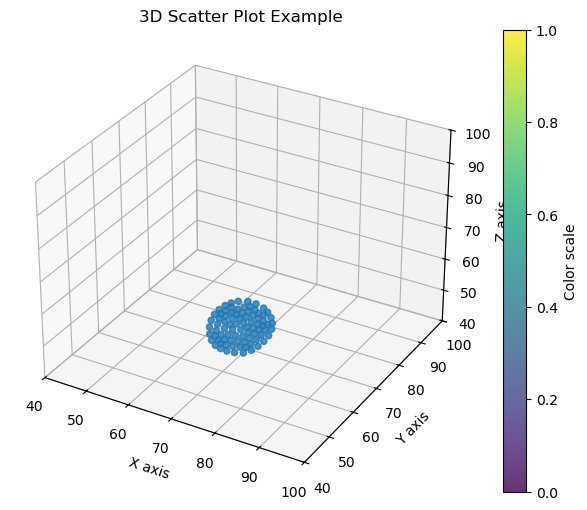

In [158]:
import matplotlib.pyplot as plt   

def scatter3D(data):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(data[:,0], data[:,1], data[:,2], cmap='viridis', alpha=0.8)
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    ax.set_title('3D Scatter Plot Example')
    ax.set_xlim(40,100)
    ax.set_ylim(40,100)
    ax.set_zlim(40,100)

    # Optional: add colorbar
    fig.colorbar(scatter, ax=ax, label='Color scale')

    plt.show()

scatter3D(graph.x[graph.is_outlet1])

In [24]:
import torch
from torch_geometric.data import Dataset, DataLoader, Data
from torch_geometric.transforms import NormalizeFeatures, Compose
from torch_geometric.utils import to_undirected
from time import perf_counter
import glob 
import pyvista as pv
import numpy as np
from itertools import combinations

def get_node_ids(mesh):
    cell_ids = np.zeros((len(mesh.points),))
    for id in np.unique(mesh['CellEntityIds']):
        cells = mesh.extract_cells(np.where(mesh['CellEntityIds'] == id)[0])['vtkOriginalPointIds']
        nodes = np.unique(cells)
        cell_ids[nodes] = id
    return cell_ids

def get_edges_tet(mesh):
    tet_cells = mesh.extract_cells(np.where(mesh['CellEntityIds'] == 0)[0])
    tet_cells = tet_cells.cells.reshape(-1, 5)[:, 1:]
    edges = np.reshape(np.array([list(combinations(cell,2)) for cell in tet_cells]), [-1,2])
    edges = torch.from_numpy(np.unique(edges, axis=0).T)
    edges = to_undirected(edges)
    return edges

def get_node_features(mesh, feature_names):
    features = torch.from_numpy(np.array([mesh.point_data[name] for name in feature_names]).T)
    return features

def set_structure_masks(data, mesh, structure_list):
    node_ids = get_node_ids(mesh)
    for id, structure in enumerate(structure_list):
            setattr(data, f"is_{structure}", torch.from_numpy(node_ids==id))
    return data

# def get_files(folder):
#     return [pat.split()]
     

def cache_data(in_path, out_path, file_list, structure_list, feature_names):
    timesteps = sorted([pat.split('/')[-1].split('.')[0].split('-')[-1] for pat in glob.glob(f'{in_path}/*')], key=lambda s: int(s))
    for file in file_list:
        start = perf_counter()
        data = Data()
        node_features = []
        for timestep in timesteps:
            print(timestep)
            mesh = pv.read(f'{in_path}/{file}-{timesteps[0]}.vtu')
            node_features.append(get_node_features(mesh, feature_names))
        data.x = torch.cat(node_features,axis=-1)
        data.x = torch.cat([torch.from_numpy(mesh.points),data.x], axis=-1)
        # data.coords = torch.from_numpy(mesh.points)
        data.edge_index = get_edges_tet(mesh)
        data = set_structure_masks(data, mesh, structure_list)
        print(perf_counter()-start)
        torch.save(data, f'{out_path}/{file}.pt')
        
columns_names = ['        pressure', '      x-velocity', '      y-velocity', '      z-velocity']
cache_data('test_data', '.', ['clipped_template'], ['volume', 'surface', 'inlet', 'outlet1', 'outlet2'], columns_names)


0301
0302
0303
0304
0305
0306
0307
0308
0309
0310
0311
0312
0313
0314
0315
0316
0317
0318
0319
0320
0321
0322
0323
0324
0325
0326
0327
0328
0329
0330
0331
0332
0333
0334
0335
0336
0337
0338
0339
0340
0341
0342
0343
0344
0345
0346
0347
0348
0349
0350
0351
0352
0353
0354
0355
0356
0357
0358
0359
0360
0361
0362
0363
0364
0365
0366
0367
0368
0369
0370
0371
0372
0373
0374
0375
0376
0377
0378
0379
0380
0381
0382
0383
0384
0385
0386
0387
0388
0389
0390
0391
0392
0393
0394
0395
0396
0397
0398
0399
0400
2.3093090830370784


In [26]:
# start = perf_counter()
graph = torch.load('clipped_template.pt')
graph.x.shape
# print(perf_counter()-start)

torch.Size([10987, 403])

In [187]:
sh = graph.x.shape
graph.x.view([sh[0],100,-1])[0,0]

tensor([ 5.3823e+01, -7.2903e-04,  4.1606e-03,  3.6265e-03],
       dtype=torch.float64)

In [166]:
import torch_geometric.transforms as T
print(graph.x)
graph = T.NormalizeFeatures()(graph)
print(graph.x)

tensor([[ 5.0768e+01,  5.0522e+01,  5.1798e+01,  ...,  5.8496e+01,
          5.9711e+01,  5.5502e+01],
        [ 7.6396e+01,  7.7539e+01,  7.7580e+01,  ...,  7.5779e+01,
          7.0331e+01,  6.7674e+01],
        [ 6.9129e+01,  7.0067e+01,  6.9066e+01,  ...,  7.7834e+01,
          7.8639e+01,  7.2540e+01],
        ...,
        [-7.2903e-04, -9.9008e-04, -8.2633e-04,  ..., -1.9169e-03,
          9.2611e-03,  1.4328e-03],
        [ 4.1606e-03,  4.8689e-03,  4.5216e-03,  ..., -7.0125e-03,
         -4.0015e-03, -6.4237e-03],
        [ 3.6265e-03,  4.3717e-03,  4.0212e-03,  ..., -1.1432e-02,
         -1.1706e-02, -5.6074e-03]], dtype=torch.float64)
tensor([[7.4242e-05, 7.3883e-05, 7.5748e-05,  ..., 8.5536e-05, 8.7312e-05,
         8.1162e-05],
        [1.0848e-04, 1.1010e-04, 1.1016e-04,  ..., 1.0760e-04, 9.9867e-05,
         9.6095e-05],
        [9.3606e-05, 9.4876e-05, 9.3521e-05,  ..., 1.0539e-04, 1.0648e-04,
         9.8223e-05],
        ...,
        [9.5502e-05, 9.4724e-05, 9.5212e-05

In [ ]:

# class FileGraphDataset(Dataset):
#     def __init__(self, root, file_list, transform=None, pre_transform=None):
#         self.file_list = file_list  # list of file paths
#         super().__init__(root, transform, pre_transform)

#     def len(self):
#         return len(self.file_list)

#     def get(self, idx):
#         # Load a single graph from file
#         data = torch.load(self.file_list[idx])
#         if self.transform:
#             data = self.transform(data)
#         return data

# # -----------------------------
# # Step 1: List all graph files
# # -----------------------------
# import glob
# file_list = glob.glob("data/graph_*.pt")

# # -----------------------------
# # Step 2: Define transforms
# # -----------------------------
# transform = Compose([
#     NormalizeFeatures(),
#     # You can add more transforms here
# ])

# # -----------------------------
# # Step 3: Initialize dataset
# # -----------------------------
# dataset = FileGraphDataset(root="data", file_list=file_list, transform=transform)

# # -----------------------------
# # Step 4: DataLoader
# # -----------------------------
# loader = DataLoader(dataset, batch_size=16, shuffle=True)

# # -----------------------------
# # Step 5: Iterate through batches
# # -----------------------------
# for batch in loader:
#     print(batch)
#     print("Batch node features shape:", batch.x.shape)
#     print("Batch edge index shape:", batch.edge_index.shape)
#     print("Batch labels shape:", batch.y.shape)
#     break

In [189]:
from torch_geometric.nn import ChebConv
from torch import nn

isinstance(ChebConv(3,2,1) ,nn.Module)

True

In [1]:
import torch
from layers import ImageEncoder,GraphDecoder,ImagetoGraph

img = torch.randn(1,1,128,128,128)
enc = ImageEncoder(in_channels=1, norm_type='BatchNorm')(img)


/Users/anirudh/miniconda3/envs/torch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
for e in enc:
    print(e.shape)

torch.Size([1, 16, 128, 128, 128])
torch.Size([1, 32, 64, 64, 64])
torch.Size([1, 64, 32, 32, 32])
torch.Size([1, 128, 16, 16, 16])
torch.Size([1, 256, 8, 8, 8])


In [ ]:
graph.coords.unsqueeze(0).unsqueeze(-2).unsqueeze(-2).shape

torch.Size([10987, 3])

In [2]:
graph = torch.load('clipped_template.pt')
projections = [ImagetoGraph()(e, graph.coords) for e in enc]
for p in projections:
    print(p.shape)
projection_ids = [[3,4],[1,2],[0,1]]


torch.Size([10987, 16])
torch.Size([10987, 32])
torch.Size([10987, 64])
torch.Size([10987, 128])
torch.Size([10987, 256])


/var/folders/6l/jpv7zwr94bv3sdj5l1tsm_lw0000gn/T/ipykernel_23622/3009850249.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load('clipped_template.pt')
/Us

In [3]:
decoder_enc_inputs = [torch.cat([projections[id[0]],projections[id[1]]], dim=-1) for id in projection_ids]
for dei in decoder_enc_inputs:
    print(dei.shape)

torch.Size([10987, 384])
torch.Size([10987, 96])
torch.Size([10987, 48])


torch.Size([2, 151876])

In [4]:
dec = GraphDecoder(encoder_channels=[384,96,48],out_channels=3)(graph.coords, graph.edge_index, decoder_enc_inputs)


In [6]:
def _get_projection_channels(filters, ids):
    channels = []
    for id_list in ids:
        sum = 0
        for id in id_list:
            sum += filters[id]
        channels.append(sum)
    return channels

_get_projection_channels(filters = [16,32,64,128,256], ids=[[3,4],[1,2],[0,1]])

[384, 96, 48]

In [1]:
import torch 
from models import SimpleI2G, get_model_config

template = torch.load('clipped_template.pt')
# template.x = torch.cat([template.coords, template.x], axis=-1).to(dtype=torch.float32)
template.x = template.x.to(dtype=torch.float32)
print(template.x.shape)
img = torch.randn(1,1,128,128,128)
config = get_model_config("Image2Flow")
model = SimpleI2G(in_channels=1, out_channels=403, **config)
out = model(img, template)

criterion = torch.nn.MSELoss()

loss = criterion(out[-1], template.x)
loss.backward()

for name, p in model.named_parameters():
    if p.grad is None:
        print(f"{name}: NO grad")
    else:
        print(f"{name}: grad OK, mean={p.grad.mean().item():.3e}")

/Users/anirudh/miniconda3/envs/torch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/6l/jpv7zwr94bv3sdj5l1tsm_lw0000gn/T/ipykernel_16138/4193451641.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.a

torch.Size([10987, 403])
Projection channels: [576, 144, 64]
torch.Size([1, 1, 128, 128, 128])
x: torch.Size([1, 1, 128, 128, 128])
torch.Size([1, 1, 128, 128, 128]) torch.Size([16, 1, 3, 3, 3])
x1: torch.Size([1, 16, 128, 128, 128])
torch.Size([1, 16, 128, 128, 128]) torch.Size([16, 16, 3, 3, 3])
x: torch.Size([1, 16, 128, 128, 128])
torch.Size([1, 16, 128, 128, 128]) torch.Size([16, 16, 3, 3, 3])
x: torch.Size([1, 16, 128, 128, 128])
torch.Size([1, 16, 128, 128, 128])
x: torch.Size([1, 16, 128, 128, 128])
torch.Size([1, 16, 128, 128, 128]) torch.Size([16, 16, 3, 3, 3])
x1: torch.Size([1, 16, 128, 128, 128])
torch.Size([1, 16, 128, 128, 128]) torch.Size([16, 16, 3, 3, 3])
x: torch.Size([1, 16, 128, 128, 128])
torch.Size([1, 16, 128, 128, 128]) torch.Size([16, 16, 3, 3, 3])
x: torch.Size([1, 16, 128, 128, 128])
torch.Size([1, 16, 64, 64, 64])
x: torch.Size([1, 16, 64, 64, 64])
torch.Size([1, 16, 64, 64, 64]) torch.Size([48, 16, 3, 3, 3])
x1: torch.Size([1, 48, 64, 64, 64])
torch.Size([

/Users/anirudh/miniconda3/envs/torch/lib/python3.10/site-packages/torch/nn/functional.py:4902: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


torch.Size([10987, 288]) torch.Size([10987, 144]) torch.Size([10987, 403])
torch.Size([10987, 96]) torch.Size([10987, 64]) torch.Size([10987, 403])
encoder.conv_blocks.0.0.initial_conv.convs.0.weight: grad OK, mean=-1.355e-03
encoder.conv_blocks.0.0.initial_conv.convs.0.bias: grad OK, mean=1.149e-03
encoder.conv_blocks.0.0.main_conv.convs.0.weight: grad OK, mean=3.116e-06
encoder.conv_blocks.0.0.main_conv.convs.0.bias: grad OK, mean=1.328e-03
encoder.conv_blocks.0.0.out_conv.convs.0.weight: grad OK, mean=7.388e-05
encoder.conv_blocks.0.0.out_conv.convs.0.bias: grad OK, mean=6.957e-04
encoder.conv_blocks.0.1.initial_conv.convs.0.weight: grad OK, mean=-1.675e-04
encoder.conv_blocks.0.1.initial_conv.convs.0.bias: grad OK, mean=2.769e-04
encoder.conv_blocks.0.1.main_conv.convs.0.weight: grad OK, mean=4.342e-05
encoder.conv_blocks.0.1.main_conv.convs.0.bias: grad OK, mean=5.899e-04
encoder.conv_blocks.0.1.out_conv.convs.0.weight: grad OK, mean=-8.766e-05
encoder.conv_blocks.0.1.out_conv.con

In [2]:
num_trainable = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(num_trainable)

34422873


In [20]:
from losses import chamfer_loss
import torch

template = torch.load('clipped_template.pt')
# template.x = torch.cat([template.coords, template.x], axis=-1).to(dtype=torch.float32)
x1 = template.coords.clone()
x2 = template.coords.clone()
x2[10] = torch.tensor([10,10,10], dtype=torch.float64)

D = torch.cdist(x1, x2)
print("D shape:", D.shape)
print("max diag:", torch.max(torch.diag(D)))
print("min diag:", torch.min(torch.diag(D)))
print("mean diag:", torch.mean(torch.diag(D)))

loss = D.min(dim=0).values.mean() + D.min(dim=1).values.mean()
print("loss:", loss.item())
# D.min(1).values.mean()+ distances.min(2).values.mean()

D shape: torch.Size([10987, 10987])
max diag: tensor(85.5754)
min diag: tensor(0.)
mean diag: tensor(0.0143)
loss: 0.02039206214249134


/var/folders/6l/jpv7zwr94bv3sdj5l1tsm_lw0000gn/T/ipykernel_78563/4083023161.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  template = torch.load('clipped_template.pt')


In [15]:
X = torch.randn(100, 3)
D = torch.cdist(X, X)**2

print(torch.mean(torch.diag(D)))
print(D.min(0).values.mean() + D.min(1).values.mean())

tensor(5.8413e-08)
tensor(1.1683e-07)


In [1]:
for i in range(10):print(i)

0
1
2
3
4
5
6
7
8
9
